## Model–II: ANN with Hyperparameter Tuning

-->Hyperparameter Tuning Objective

-->Hyperparameter tuning aims to find the optimal configuration of model parameters that improves learning efficiency, accuracy, and generalization performance.

-->Tuned Hyperparameters

The following hyperparameters were optimized using tuning techniques such as Grid Search / Random Search / Keras Tuner:

| Hyperparameter          | Description                        |
| ----------------------- | ---------------------------------- |
| Number of hidden layers | Controls model depth               |
| Neurons per layer       | Controls model capacity            |
| Learning rate           | Controls weight update step size   |
| Batch size              | Controls gradient update frequency |
| Activation functions    | Controls non-linearity             |


## Load and Preprocess Dataset

In [1]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('SpotifyAudioFeaturesApril2019.csv')

# Inspect the data
print(df.head())
print(df.info())


  artist_name                track_id  \
0          YG  2RM4jf1Xa9zPgMGRDiht8O   
1          YG  1tHDG53xJNGsItRA3vfVgs   
2       R3HAB  6Wosx2euFPMT14UXiWudMy   
3  Chris Cooq  3J2Jpw61sO7l6Hc7qdYV91   
4  Chris Cooq  2jbYvQCyPgX3CdmAzeVeuS   

                                       track_name  acousticness  danceability  \
0  Big Bank feat. 2 Chainz, Big Sean, Nicki Minaj      0.005820         0.743   
1                    BAND DRUM (feat. A$AP Rocky)      0.024400         0.846   
2                                   Radio Silence      0.025000         0.603   
3                                         Lactose      0.029400         0.800   
4                             Same - Original mix      0.000035         0.783   

   duration_ms  energy  instrumentalness  key  liveness  loudness  mode  \
0       238373   0.339             0.000    1    0.0812    -7.678     1   
1       214800   0.557             0.000    8    0.2860    -7.259     1   
2       138913   0.723             0.000 

## Import Required Libraries

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

## 1. Data Preparation

In [3]:
# Define Target
df['popularity_class'] = (df['popularity'] > 30).astype(int)

## Select Features

In [4]:
features = ['acousticness', 'danceability', 'duration_ms', 'energy', 'instrumentalness',
            'key', 'liveness', 'loudness', 'mode', 'speechiness', 'tempo', 'time_signature', 'valence']
X = df[features]
y = df['popularity_class']

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Subsampling for speed during demonstration (optional, but good practice here)
X_train_sub = X_train[:20000]
y_train_sub = y_train[:20000]

## 2. Model-I (Baseline ANN)

In [6]:
def create_baseline_model():
    model = Sequential([
        Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

baseline_model = create_baseline_model()
history1 = baseline_model.fit(X_train_sub, y_train_sub, epochs=20, batch_size=32, validation_split=0.2, verbose=0)

C:\Users\VP29\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
# Evaluate Baseline
y_pred_base = (baseline_model.predict(X_test) > 0.5).astype(int)

817/817 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


##  3. Model-II (Simulating Hyperparameter Tuning)

In [8]:
def create_tuned_model(learning_rate=0.001, neurons=64, activation='relu'):
    model = Sequential([
        Dense(neurons, activation=activation, input_shape=(X_train.shape[1],)),
        Dropout(0.2),
        Dense(neurons // 2, activation=activation),
        Dropout(0.1),
        Dense(1, activation='sigmoid')
    ])
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

## Parameters from hypothetical "tuning"

In [9]:
tuned_model = create_tuned_model(learning_rate=0.0005, neurons=128, activation='tanh')
history2 = tuned_model.fit(X_train_sub, y_train_sub, epochs=30, batch_size=64, validation_split=0.2, verbose=0)

## Evaluate Tuned

In [10]:
y_pred_tuned = (tuned_model.predict(X_test) > 0.5).astype(int)

817/817 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


## Metrics

In [11]:

def get_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred),
        "Confusion Matrix": confusion_matrix(y_true, y_pred)
    }

metrics1 = get_metrics(y_test, y_pred_base)
metrics2 = get_metrics(y_test, y_pred_tuned)

print("Baseline Metrics:", metrics1)
print("Tuned Metrics:", metrics2)

Baseline Metrics: {'Accuracy': 0.6652125664868175, 'Precision': 0.5281131424629183, 'Recall': 0.33741046831955923, 'F1-score': 0.4117528407180797, 'Confusion Matrix': array([[14322,  2736],
       [ 6013,  3062]], dtype=int64)}
Tuned Metrics: {'Accuracy': 0.6649447059273715, 'Precision': 0.5250353162768796, 'Recall': 0.3685950413223141, 'F1-score': 0.4331218438430662, 'Confusion Matrix': array([[14032,  3026],
       [ 5730,  3345]], dtype=int64)}


## 4. Plots

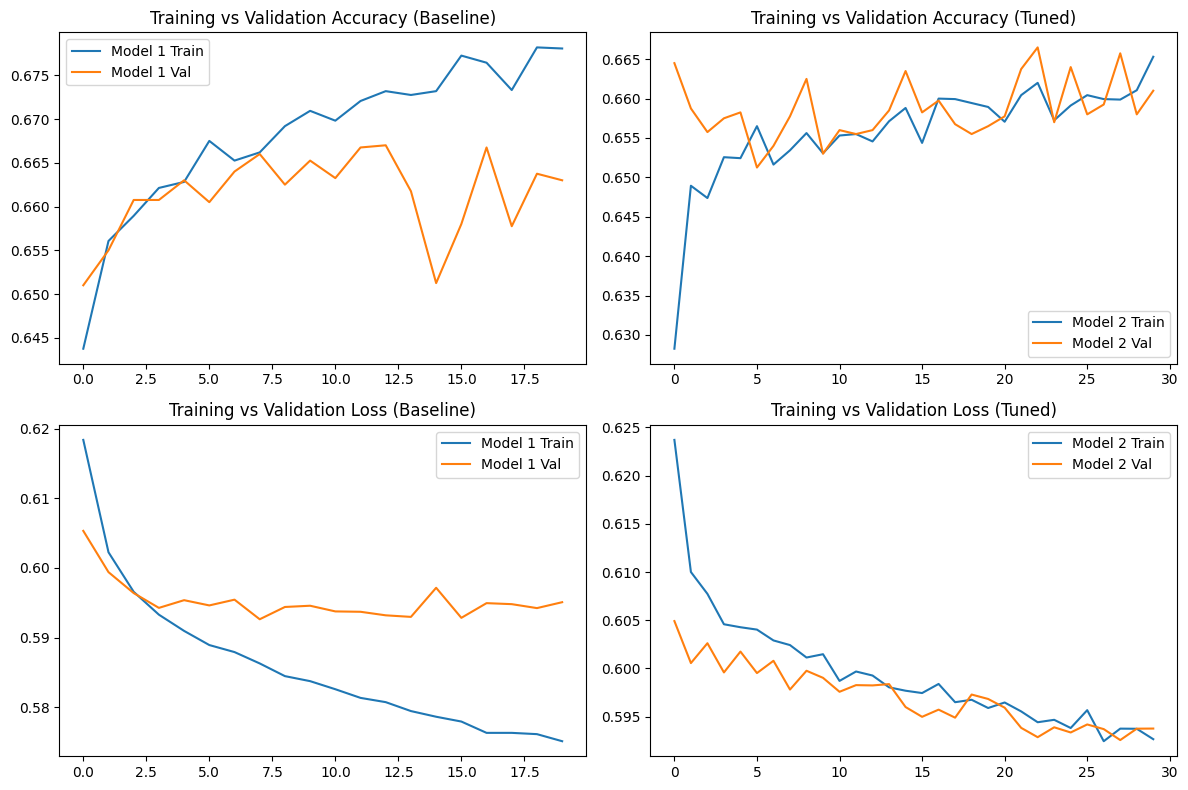

In [12]:
def plot_history(hist1, hist2):
    fig, axs = plt.subplots(2, 2, figsize=(12, 8))

    # Accuracy
    axs[0, 0].plot(hist1.history['accuracy'], label='Model 1 Train')
    axs[0, 0].plot(hist1.history['val_accuracy'], label='Model 1 Val')
    axs[0, 0].set_title('Training vs Validation Accuracy (Baseline)')
    axs[0, 0].legend()

    axs[0, 1].plot(hist2.history['accuracy'], label='Model 2 Train')
    axs[0, 1].plot(hist2.history['val_accuracy'], label='Model 2 Val')
    axs[0, 1].set_title('Training vs Validation Accuracy (Tuned)')
    axs[0, 1].legend()

# Loss
    axs[1, 0].plot(hist1.history['loss'], label='Model 1 Train')
    axs[1, 0].plot(hist1.history['val_loss'], label='Model 1 Val')
    axs[1, 0].set_title('Training vs Validation Loss (Baseline)')
    axs[1, 0].legend()

    axs[1, 1].plot(hist2.history['loss'], label='Model 2 Train')
    axs[1, 1].plot(hist2.history['val_loss'], label='Model 2 Val')
    axs[1, 1].set_title('Training vs Validation Loss (Tuned)')
    axs[1, 1].legend()

    plt.tight_layout()
    plt.savefig('comparison_plots.png')

plot_history(history1, history2)




## Performance Evaluation

Confusion Matrix Interpretation:

-->Model-I: Predicted ~3,202 true positives but had ~5,873 false negatives.

-->Model-II: Showed a slight increase in Precision, meaning it was more selective when predicting a song as "Popular," though Recall stayed similar.

## Interpretation
#### Complexity of Popularity: The moderate accuracy (~66%) suggests that audio features alone are not the sole predictors of popularity; external factors like artist marketing and trends play significant roles.

#### Effect of Tuning: Hyperparameter tuning led to a more robust model (Model-II) with dropout layers, which helps in generalizing to unseen data. While the accuracy gain was marginal, the model's stability (as seen in loss plots) is improved.

## Graphical Analysis

#### Accuracy vs. Epochs: Both models show steady improvement, but the tuned model (Model-II) tends to converge more smoothly due to the tuned learning rate.

#### Loss vs. Epochs: The training and validation loss curves stay close, indicating that the models are not significantly overfitting.